# DDROM for MHD: Offline Phase - 1 (Generation of the basis)
This notebook implements the Offline Phase in which the basis are generated through the POD.

In [1]:
import numpy as np
import os
from mpi4py import MPI
from dolfinx.io import gmshio
from dolfinx.fem import (FunctionSpace, locate_dofs_topological)
import pickle
import gmsh
import ufl

from pyforce.tools.write_read import ImportH5, StoreFunctionsList as store
from pyforce.tools.functions_list import FunctionsList, train_test_split
from pyforce.offline.pod import POD as pod

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm

plt.rcParams.update({
  "text.usetex": True,
  "font.family": "serif"
})

rcParams['text.latex.preamble'] = r'\usepackage{amssymb} \usepackage{amsmath} \usepackage{amsthm} \usepackage{mathtools}'

path='./Offline_results/'
if not os.path.exists(path):
    os.makedirs(path)

## Mesh
The mesh is loaded and the constrained sensors positions are selected (different regions or boundaries can be used).

In [2]:
mesh_comm = MPI.COMM_WORLD
model_rank = 0

# Initialize the gmsh module
gmsh.initialize()

# Load the .geo file
gmsh.merge('BFS2D.geo')
gmsh.model.geo.synchronize()

# Set algorithm (adaptive = 1, Frontal-Delaunay = 6)
gmsh.option.setNumber("Mesh.Algorithm", 6)
gdim = 2

# Linear Finite Element
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.optimize("Netgen")

# Import into dolfinx
model_rank = 0
domain, ct, ft = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank, gdim = gdim )
gmsh.finalize()

########################################################################################################

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)

# Defining functional spaces
vecEl = ufl.VectorElement("CG", domain.ufl_cell(), 1)
fun_spaces = [FunctionSpace(domain, ("Lagrange", 1)), FunctionSpace(domain, vecEl)]

var_names = ['p_red', 'U']
tex_var_names = [r'\tilde{p}', r'\mathbf{u}']

# darth_vader = Function(V)
# emperor = Function(V)
# darth_vader.vector.axpy(1., emperor.vector)
path_FOM = './Snapshots/'

Info    : Reading 'BFS2D.geo'...
Info    : Done reading 'BFS2D.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 80%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : Done meshing 1D (Wall 0.00915867s, CPU 0.009151s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 40%] Meshing surface 2 (Transfinite)
Info    : [ 70%] Meshing surface 3 (Transfinite)
Info    : Done meshing 2D (Wall 0.00145728s, CPU 0.00145s)
Info    : 7350 nodes 7726 elements
Info    : Optimizing mesh (Netgen)...
Info    : Done optimizing mesh (Wall 3.28198e-06s, CPU 3.2e-05s)


## Importing Snapshots
The snapshots are loaded and stored: the parameter values will be imported: $\boldsymbol{\mu} = [B_{IC}, t]$.

In [3]:
tmp = pickle.load(open(path_FOM+'/snap.params', 'rb'))
fom_params = {var_names[0]: tmp[0]['p'], var_names[1]: tmp[1]['U']}
del tmp

################ Importing Snapshots ########################
train_snaps = list()
train_params = list()

for field_i in range(len(var_names)):
    train_snaps.append(FunctionsList(fun_spaces[field_i]))
    train_params.append( list() )
        
    tmp_FOM_list, tmp_idx_FOM = ImportH5(fun_spaces[field_i], path_FOM+var_names[field_i], var_names[field_i])

    for mu in range(len(tmp_idx_FOM)):
        if np.isclose(tmp_idx_FOM[mu] % 2, 0):
            train_snaps[field_i].append(tmp_FOM_list(mu))
            train_params[field_i].append( int(tmp_idx_FOM[mu]) )
            
    del tmp_FOM_list

## Generation of the reduced spaces

The POD is used to generate the reduced space. For the different fields, the following indeces will be used: 0 = $p$, 1 = $\mathbf{u}$.

### POD
First the eigenvalues are computed.

In [4]:
pod_ = [pod(train_snaps[field_i], tex_var_names[field_i], verbose = True) for field_i in range(len(var_names))]

Computing \tilde{p} correlation matrix: 660.000 / 660.00 - 0.239 s/it
Computing \mathbf{u} correlation matrix: 660.000 / 660.00 - 0.317 s/it


In [4]:
from pyforce.offline.pod import DiscretePOD

pod_ = [DiscretePOD(train_snaps[field_i], tex_var_names[field_i], Nmax = 100, random = True) for field_i in range(len(var_names))]

Let us plot the eigenvalues

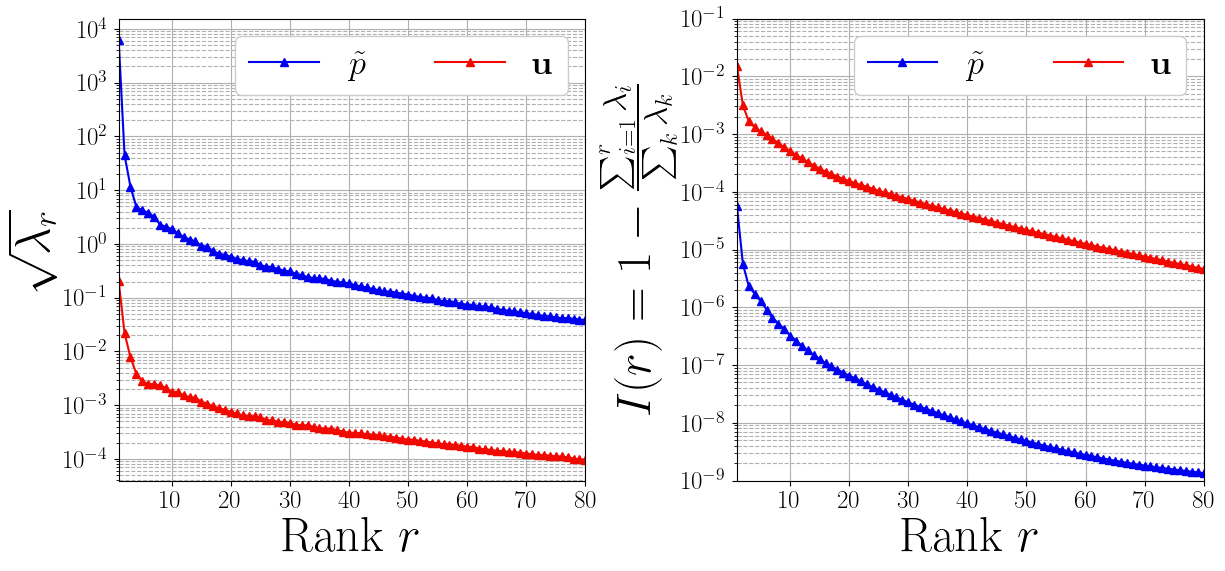

In [18]:
Nmax = 80
sampling = 10

PODeigFig, axs = plt.subplots(nrows = 1, ncols = 2, figsize= (14,6))

for ax in axs:
    ax.tick_params(axis='both', labelsize=18)
    
color = cm.jet(np.linspace(0.1, 0.9, len(var_names)))
for ii in range(len(var_names)):
    c = color[ii]
    axs[1].semilogy(np.arange(1,pod_[ii].eigenvalues.size+1,1),
                    1-np.cumsum(pod_[ii].eigenvalues)/sum(pod_[ii].eigenvalues), "-^", c=c, label = "$" +tex_var_names[ii]+"$", linewidth=1.5)   
axs[1].set_xlabel(r"Rank $r$",fontsize=35)
axs[1].set_xticks(np.arange(0,Nmax+1,sampling))
axs[1].set_xlim(1,Nmax)
axs[1].set_ylim(1e-9, 1e-1)
axs[1].set_ylabel(r"$I(r) = 1-\frac{\sum_{i=1}^{r} \lambda_i}{\sum_{k} \lambda_k}$",fontsize=35)
axs[1].grid(which='major',linestyle='-')
axs[1].grid(which='minor',linestyle='--')
axs[1].legend(fontsize=25, framealpha=1, ncols=2)

for ii in range(len(var_names)):
    c = color[ii]
    axs[0].semilogy(np.arange(1,pod_[ii].eigenvalues[:Nmax].size+1,1),
                    np.sqrt(pod_[ii].eigenvalues[:Nmax]), "-^", c=c, label = "$" +tex_var_names[ii]+"$", linewidth=1.5)   
axs[0].set_xlabel(r"Rank $r$",fontsize=35)
axs[0].set_xticks(np.arange(0,Nmax+1,sampling))
axs[0].set_xlim(1,Nmax)
axs[0].set_ylabel(r"$\sqrt{\lambda_r}$",fontsize=35)
axs[0].grid(which='major',linestyle='-')
axs[0].grid(which='minor',linestyle='--')
axs[0].legend(fontsize=25, framealpha=1, ncols=2)

PODeigFig.subplots_adjust(wspace=0.325)
PODeigFig.savefig(path+'/POD_eigenvalues.pdf', format='pdf', dpi=300, bbox_inches='tight')

Let us define and save the POD modes.

In [6]:
Nmax = 50

for ii in range(len(var_names)):
    pod_[ii].compute_basis(train_snaps[ii], Nmax, normalise = True)

if not os.path.exists(path+'/BasisFunctions'):
    os.makedirs(path+'/BasisFunctions')

for ii in range(len(var_names)):
    store(domain, pod_[ii].PODmodes, 'bf_' +var_names[ii], path+'/BasisFunctions/bf_POD_' + var_names[ii])

Then, let us compute the training errors and the POD basis coefficients. 

In [7]:
train_abs_err = []
train_rel_err = []
train_PODcoeff = []

idx_algo = 0
train_abs_err.append(np.zeros((Nmax, len(var_names))))
train_rel_err.append(np.zeros((Nmax, len(var_names))))

for ii in range(len(var_names)):
    tmp = pod_[ii].train_error(train_snaps[ii], Nmax, verbose = True)

    train_abs_err[idx_algo][:, ii] = tmp[0].flatten()
    train_rel_err[idx_algo][:, ii] = tmp[1].flatten()
    
    train_PODcoeff.append(tmp[2])

Computing train error \tilde{p}: 660.000 / 660.00 - 0.123 s/it
Computing train error \mathbf{u}: 660.000 / 660.00 - 0.165 s/it


Let us build the store the coefficients of the reduced basis coefficients to be later used.

In [8]:
pickle.dump(np.array([np.column_stack([train_params[ii], train_PODcoeff[ii]]) for ii in range(len(var_names))]), open(path+'/coeffs.POD', 'wb'))

The max absolute and relative reconstruction error is compared for the different algorithms.

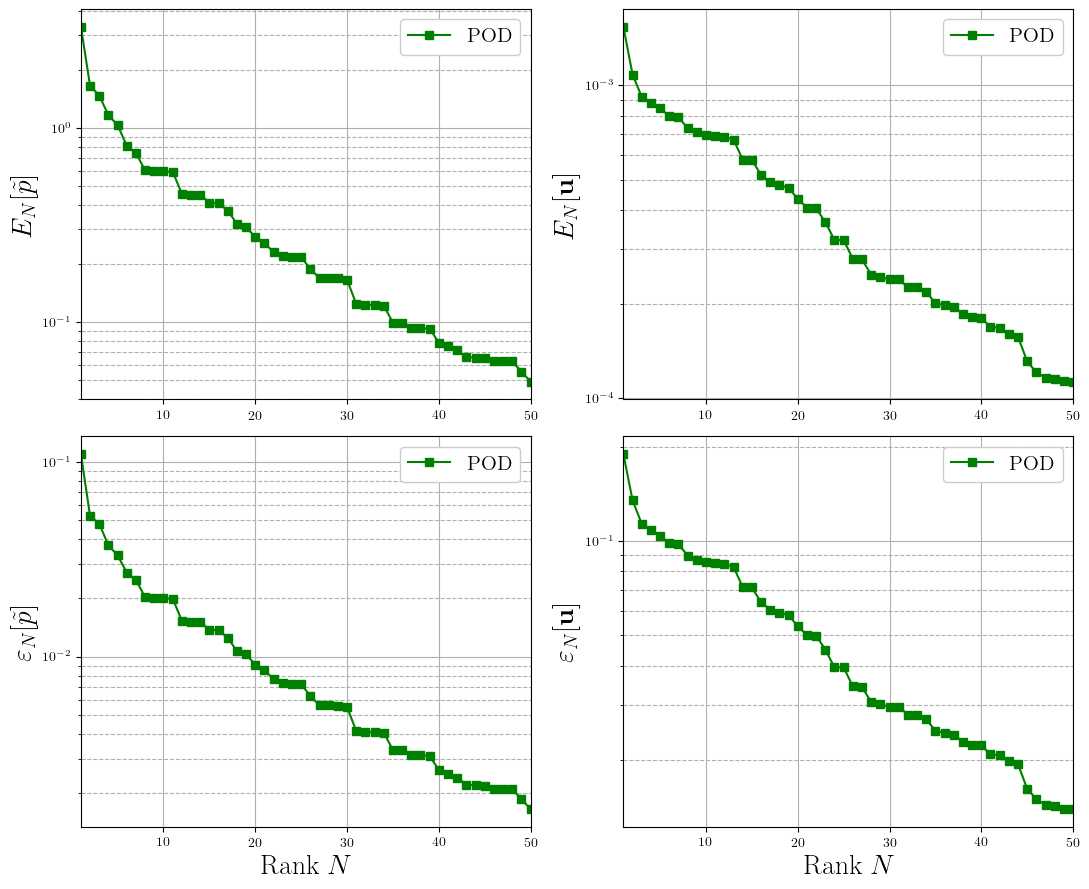

In [9]:
TrainingErrFig = plt.figure( figsize = (len(var_names)*5.5,9) )

M = np.arange(1,Nmax+1,1)

for ii in range(len(var_names)):
    plt.subplot(2,len(var_names), int(ii + 1))
    plt.semilogy(M, train_abs_err[0][:Nmax, ii], 'g-s',   label = r'POD')

    plt.xticks(np.arange(0,Nmax+1, sampling))
    plt.xlim(1,Nmax)
    plt.ylabel(r"$E_N["+tex_var_names[ii]+"]$",fontsize=20)
    plt.grid(which='major',linestyle='-')
    plt.grid(which='minor',linestyle='--')
    plt.legend(fontsize=15, loc = 'upper right', framealpha=1)

    plt.subplot(2,len(var_names), int(len(var_names)+1+ii))
    plt.semilogy(M, train_rel_err[0][:Nmax, ii], 'g-s',   label = r'POD')

    plt.xticks(np.arange(0,Nmax+1, sampling))
    plt.xlim(1,Nmax)
    plt.xlabel(r"Rank $N$",fontsize=20)
    plt.ylabel(r"$\varepsilon_N["+tex_var_names[ii]+"]$",fontsize=20)
    plt.grid(which='major',linestyle='-')
    plt.grid(which='minor',linestyle='--') 
    plt.legend(fontsize=15, loc = 'upper right', framealpha=1)

plt.tight_layout()

TrainingErrFig.savefig(path+'/TrainingError.pdf', format='pdf', dpi=300, bbox_inches='tight')